In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

import string
import os

In [3]:
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to C:\Users\K
[nltk_data]     K\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package stopwords to C:\Users\K
[nltk_data]     K\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

In [4]:
graph_folder = r"D:\Datascience_Internship\Prodigy_Task4\graphs"

os.makedirs(graph_folder, exist_ok=True)

In [5]:
df = pd.read_csv(
    r"D:\Datascience_Internship\Prodigy_Task4\twitter_training.csv",
    header=None
)

df.columns=[
    "ID",
    "Topic",
    "Sentiment",
    "Tweet"
]

df.head()

,ID,Topic,Sentiment,Tweet
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


In [6]:
print(df.shape)

df.info()

df.describe(include='all')


(74682, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74682 entries, 0 to 74681
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   ID         74682 non-null  int64 
 1   Topic      74682 non-null  object
 2   Sentiment  74682 non-null  object
 3   Tweet      73996 non-null  object
dtypes: int64(1), object(3)
memory usage: 2.3+ MB


,ID,Topic,Sentiment,Tweet
count,74682.000000,74682,74682,73996
unique,NaN,32,4,69491
top,NaN,TomClancysRainbowSix,Negative,"At the same time, despite the fact that there ..."
freq,NaN,2400,22542,172
mean,6432.586165,NaN,NaN,NaN
std,3740.427870,NaN,NaN,NaN
min,1.000000,NaN,NaN,NaN
25%,3195.000000,NaN,NaN,NaN
50%,6422.000000,NaN,NaN,NaN
75%,9601.000000,NaN,NaN,NaN


In [7]:
print(df.isnull().sum())

df.dropna(inplace=True)

ID             0
Topic          0
Sentiment      0
Tweet        686
dtype: int64


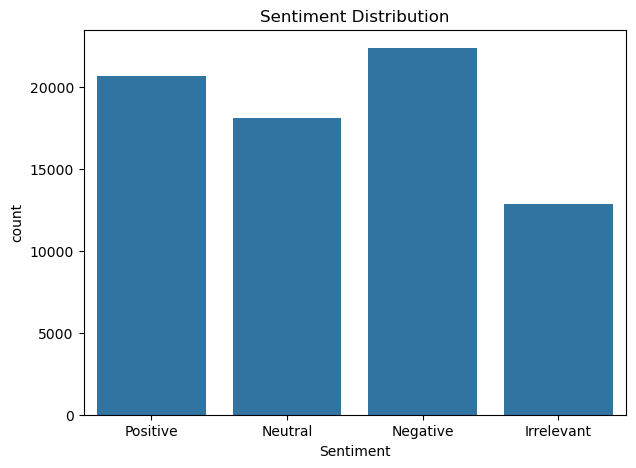

In [8]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="Sentiment"
)

plt.title("Sentiment Distribution")

plt.savefig(
    os.path.join(graph_folder,"Sentiment_Distribution.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

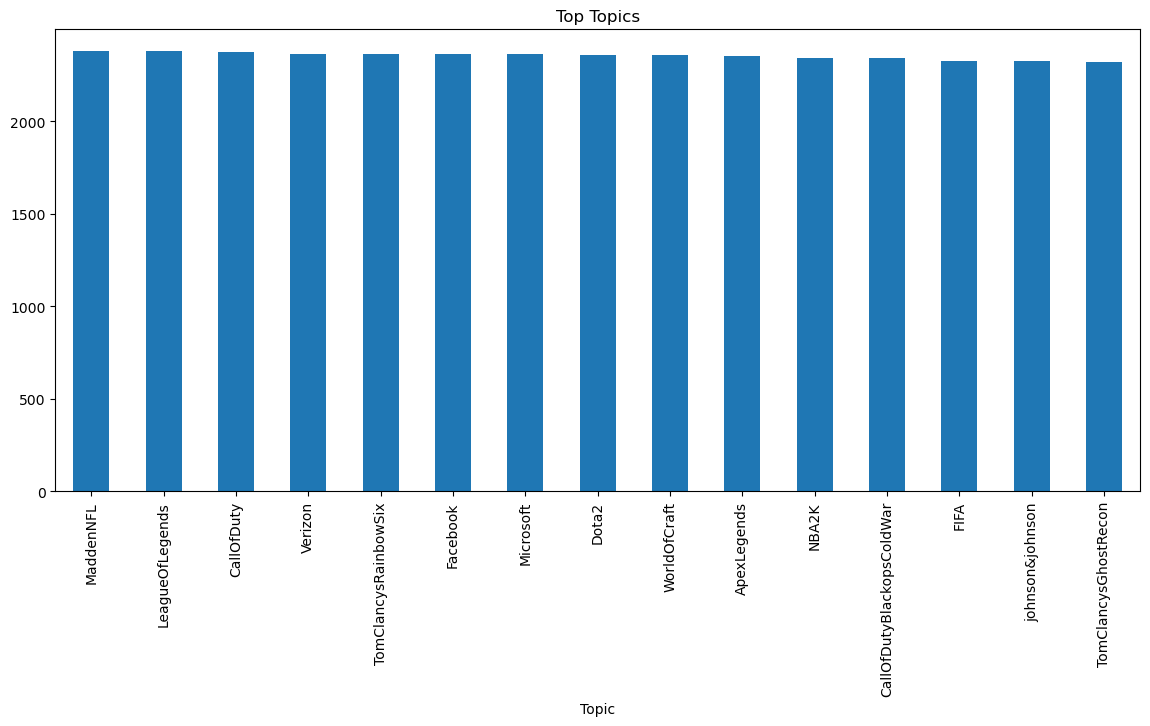

In [9]:
plt.figure(figsize=(14,6))

df["Topic"].value_counts().head(15).plot(kind="bar")

plt.title("Top Topics")

plt.savefig(
    os.path.join(graph_folder,"Top_Topics.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

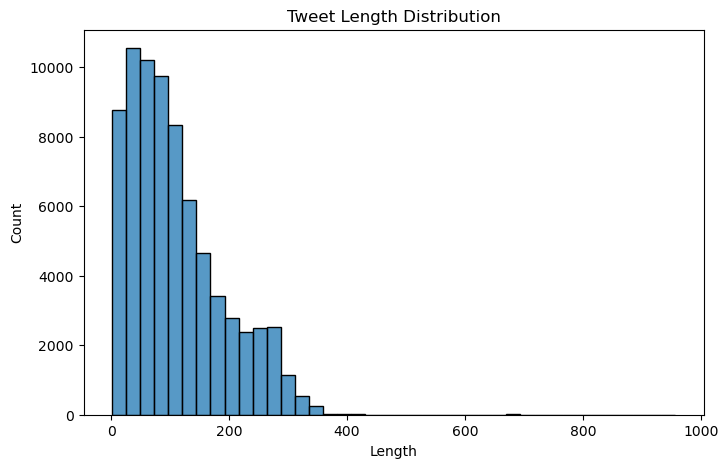

In [10]:
df["Length"]=df["Tweet"].astype(str).apply(len)

plt.figure(figsize=(8,5))

sns.histplot(df["Length"],bins=40)

plt.title("Tweet Length Distribution")

plt.savefig(
    os.path.join(graph_folder,"Tweet_Length.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [13]:
stop_words=set(stopwords.words('english'))

def clean_text(text):

    text=str(text).lower()

    text=text.translate(
        str.maketrans('','',string.punctuation)
    )

    words=word_tokenize(text)

    words=[
        word
        for word in words
        if word not in stop_words
    ]

    return " ".join(words)

df["Clean_Tweet"]=df["Tweet"].apply(clean_text)

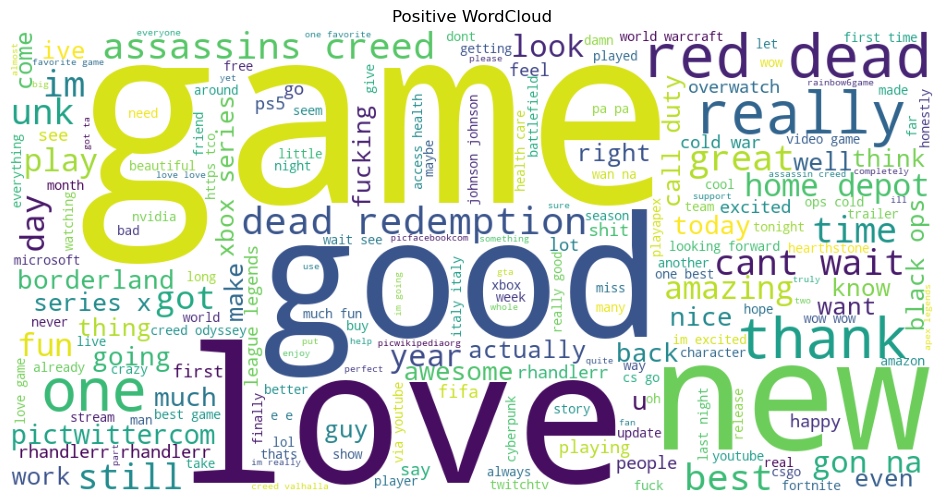

In [14]:
positive_text=" ".join(
    df[df["Sentiment"]=="Positive"]["Clean_Tweet"]
)

wordcloud=WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(positive_text)

plt.figure(figsize=(12,6))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Positive WordCloud")

plt.savefig(
    os.path.join(graph_folder,"Positive_WordCloud.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

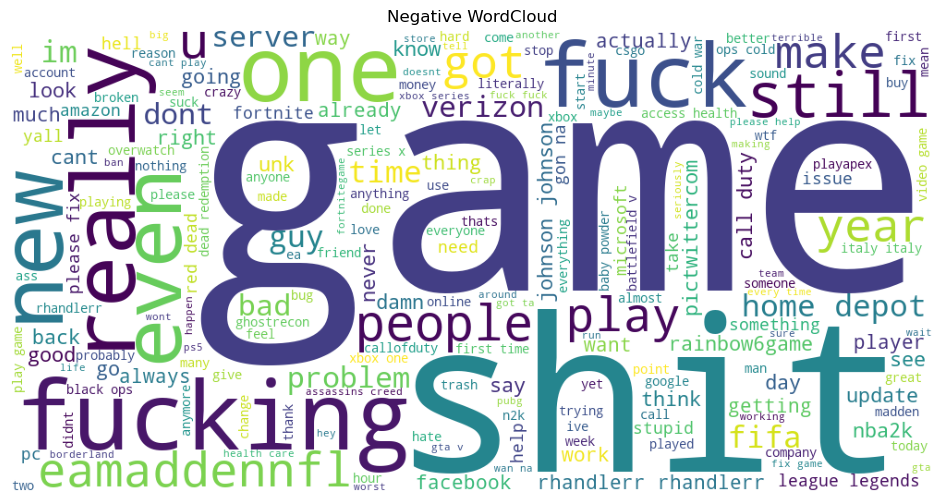

In [15]:
negative_text=" ".join(
    df[df["Sentiment"]=="Negative"]["Clean_Tweet"]
)

wordcloud=WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(negative_text)

plt.figure(figsize=(12,6))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Negative WordCloud")

plt.savefig(
    os.path.join(graph_folder,"Negative_WordCloud.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

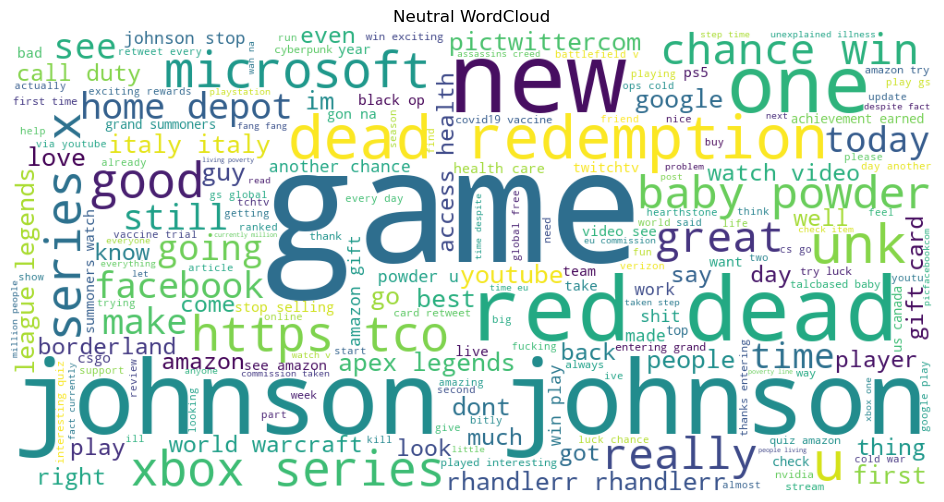

In [16]:
neutral_text=" ".join(
    df[df["Sentiment"]=="Neutral"]["Clean_Tweet"]
)

wordcloud=WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(neutral_text)

plt.figure(figsize=(12,6))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Neutral WordCloud")

plt.savefig(
    os.path.join(graph_folder,"Neutral_WordCloud.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

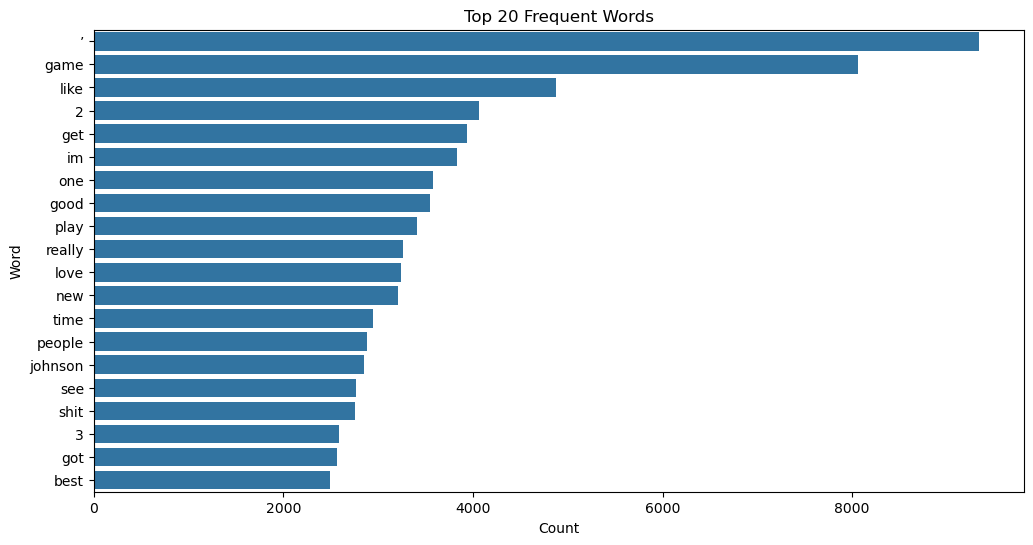

In [17]:
from collections import Counter

words=" ".join(df["Clean_Tweet"]).split()

counter=Counter(words)

common=counter.most_common(20)

common_df=pd.DataFrame(
    common,
    columns=["Word","Count"]
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=common_df,
    x="Count",
    y="Word"
)

plt.title("Top 20 Frequent Words")

plt.savefig(
    os.path.join(graph_folder,"Top20Words.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

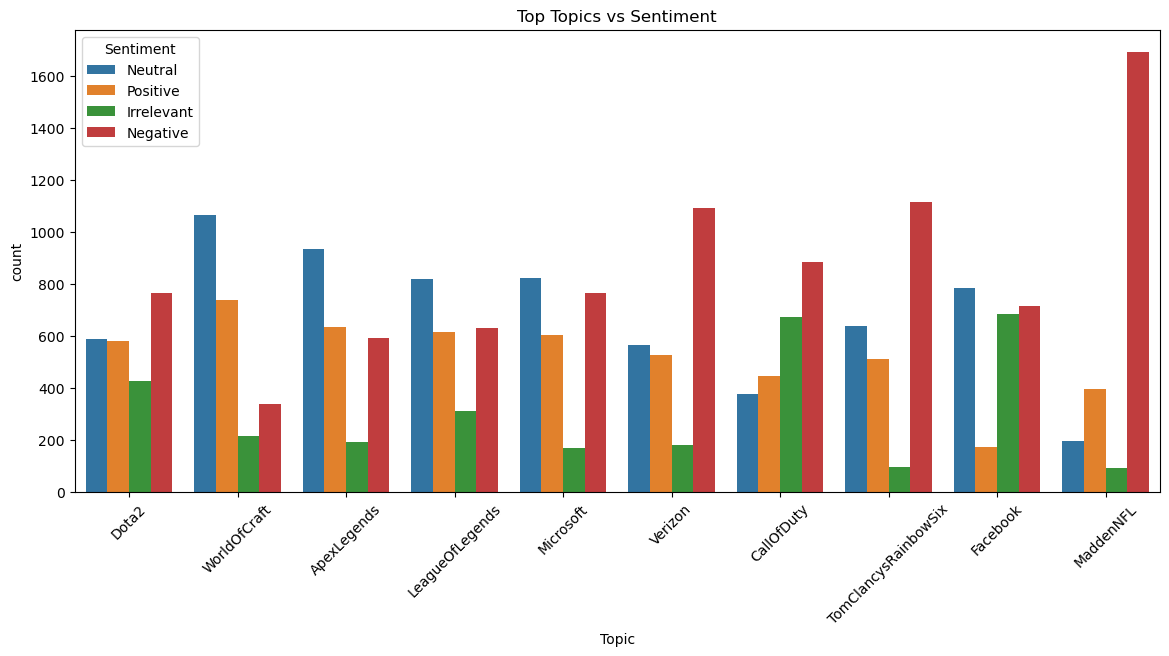

In [18]:
top_topics=df["Topic"].value_counts().head(10).index

subset=df[df["Topic"].isin(top_topics)]

plt.figure(figsize=(14,6))

sns.countplot(
    data=subset,
    x="Topic",
    hue="Sentiment"
)

plt.xticks(rotation=45)

plt.title("Top Topics vs Sentiment")

plt.savefig(
    os.path.join(graph_folder,"Topic_vs_Sentiment.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

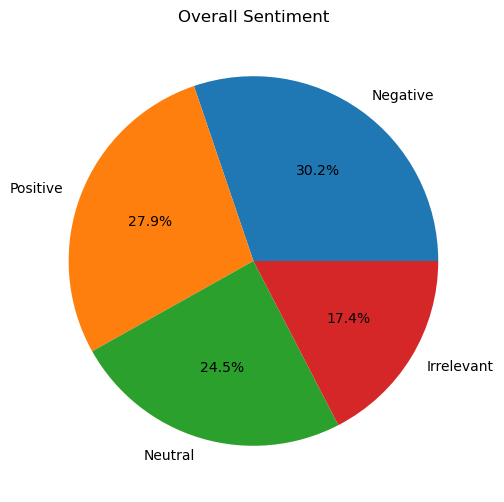

In [19]:
plt.figure(figsize=(6,6))

df["Sentiment"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")

plt.title("Overall Sentiment")

plt.savefig(
    os.path.join(graph_folder,"Sentiment_Pie.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [20]:
print("="*60)

print("TASK-04 COMPLETED SUCCESSFULLY")

print("="*60)

print("Dataset Shape :",df.shape)

print()

print(df["Sentiment"].value_counts())

print()

print("Graphs saved in:")

print(graph_folder)

TASK-04 COMPLETED SUCCESSFULLY
Dataset Shape : (73996, 6)

Sentiment
Negative      22358
Positive      20655
Neutral       18108
Irrelevant    12875
Name: count, dtype: int64

Graphs saved in:
D:\Datascience_Internship\Prodigy_Task4\graphs
